In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path
from datetime import datetime

In [2]:
ruta = Path("..") / "Data" / "dataset"

dataframes = {}

for archivo in ruta.glob("*.csv"):
    dataframes[archivo.stem] = pd.read_csv(archivo)

In [3]:
customers = dataframes['customers']
delivery_events = dataframes['delivery_events']
drivers = dataframes['drivers']
driver_monthly_metrics = dataframes['driver_monthly_metrics']
facilities = dataframes['facilities']
fuel_purchases = dataframes['fuel_purchases']
loads = dataframes['loads']
maintenance_records = dataframes['maintenance_records']
routes = dataframes['routes']
safety_incidents = dataframes['safety_incidents']
trailers = dataframes['trailers']
trips = dataframes['trips']
trucks = dataframes['trucks']
truck_utilization_metrics = dataframes['truck_utilization_metrics']

In [4]:
delivery_events['scheduled_datetime'] = pd.to_datetime(delivery_events['scheduled_datetime'])
delivery_events['actual_datetime'] = pd.to_datetime(delivery_events['actual_datetime'])
driver_monthly_metrics['month'] = pd.to_datetime(driver_monthly_metrics['month'])
fuel_purchases['purchase_date'] = pd.to_datetime(fuel_purchases['purchase_date'])
loads['load_date'] = pd.to_datetime(loads['load_date'])
maintenance_records['maintenance_date'] = pd.to_datetime(maintenance_records['maintenance_date'])
safety_incidents['incident_date'] = pd.to_datetime(safety_incidents['incident_date'])
trailers['acquisition_date'] = pd.to_datetime(trailers['acquisition_date'])
trips['dispatch_date'] = pd.to_datetime(trips['dispatch_date'])
trucks['acquisition_date'] = pd.to_datetime(trucks['acquisition_date'])
truck_utilization_metrics['month'] = pd.to_datetime(truck_utilization_metrics['month'])

In [5]:
delivery_events['arrivel_delay_minutes'] = ((delivery_events['actual_datetime'] - delivery_events['scheduled_datetime']).dt.total_seconds() / 60).round(2)
delivery_events.head()

,event_id,load_id,trip_id,event_type,facility_id,scheduled_datetime,actual_datetime,detention_minutes,on_time_flag,location_city,location_state,arrivel_delay_minutes
0,EVT00000001,LOAD00000001,TRIP00000001,Pickup,FAC00034,2022-01-01 18:00:00.000000,2022-01-01 20:58:55.918185,0,False,Houston,TX,178.93
1,EVT00000002,LOAD00000001,TRIP00000001,Delivery,FAC00046,2022-01-02 23:10:55.918185,2022-01-02 21:30:22.142060,230,True,Detroit,MI,-100.56
2,EVT00000003,LOAD00000002,TRIP00000002,Pickup,FAC00015,2022-01-01 18:00:00.000000,2022-01-01 17:37:26.608430,62,True,Kansas City,MO,-22.56
3,EVT00000004,LOAD00000002,TRIP00000002,Delivery,FAC00050,2022-01-02 02:13:26.608430,2022-01-02 05:55:46.238257,67,False,Indianapolis,IN,222.33
4,EVT00000005,LOAD00000003,TRIP00000003,Pickup,FAC00001,2022-01-01 08:00:00.000000,2022-01-01 07:28:02.169634,83,True,Columbus,OH,-31.96


*** 3.1- Rendimiento de los conductores ***

In [6]:
drivers['employment_status'].unique()

array(['Active', 'Terminated'], dtype=object)

In [7]:
driver_monthly_metrics.head()

,driver_id,month,trips_completed,total_miles,total_revenue,average_mpg,total_fuel_gallons,on_time_delivery_rate,average_idle_hours
0,DRV00001,2022-01-01,26,36620,79141.59,6.61,5574.7,0.385,8.2
1,DRV00001,2022-02-01,9,13515,27133.87,6.69,2095.1,0.333,6.8
2,DRV00001,2022-03-01,20,30361,62399.62,6.36,4792.2,0.550,7.5
3,DRV00001,2022-04-01,19,28127,68161.13,6.61,4251.4,0.474,8.4
4,DRV00001,2022-05-01,14,16071,36256.82,6.35,2573.1,0.214,6.8


In [8]:
driver_monthly_metrics.describe().T

,count,mean,min,25%,50%,75%,max,std
month,4464,2023-06-16 18:40:00,2022-01-01 00:00:00,2022-09-23 12:00:00,2023-06-16 00:00:00,2024-03-08 18:00:00,2024-12-01 00:00:00,NaN
trips_completed,4464.0,18.749104,5.0,16.0,19.0,22.0,37.0,4.38708
total_miles,4464.0,26812.792339,3310.0,21783.0,26409.5,31474.75,57954.0,7253.534265
total_revenue,4464.0,57630.947713,7096.56,46314.0525,56652.715,67964.8075,124579.53,15899.349196
average_mpg,4464.0,6.501862,6.01,6.41,6.5,6.6,7.07,0.140353
total_fuel_gallons,4464.0,4158.631698,521.9,3372.5,4083.95,4882.4,9007.5,1132.037704
on_time_delivery_rate,4464.0,0.445996,0.0,0.364,0.444,0.526,0.833,0.119988
average_idle_hours,4464.0,7.011738,4.4,6.6,7.0,7.5,9.7,0.683257


Luego de ver como se manifiestan las variables, se desarrolla una matriz de correlación de las principales variables numéricas para ver cuales están más relacionadas con el rendimiento de los conductores.

In [9]:
driver_corr = driver_monthly_metrics[                   
       ['trips_completed',
        'total_miles',
        'total_revenue',
        'average_mpg',
        'total_fuel_gallons',
        'on_time_delivery_rate',
        'average_idle_hours']]

corr_matrix = driver_corr.corr(method='pearson')

corr_matrix

,trips_completed,total_miles,total_revenue,average_mpg,total_fuel_gallons,on_time_delivery_rate,average_idle_hours
trips_completed,1.000000,0.868923,0.850158,-0.006399,0.865671,0.007467,-0.013227
total_miles,0.868923,1.000000,0.981380,-0.007974,0.996030,0.005050,-0.004594
total_revenue,0.850158,0.981380,1.000000,-0.007190,0.977277,0.003813,-0.002885
average_mpg,-0.006399,-0.007974,-0.007190,1.000000,-0.083407,0.016887,-0.013048
total_fuel_gallons,0.865671,0.996030,0.977277,-0.083407,1.000000,0.002530,-0.002376
on_time_delivery_rate,0.007467,0.005050,0.003813,0.016887,0.002530,1.000000,-0.001643
average_idle_hours,-0.013227,-0.004594,-0.002885,-0.013048,-0.002376,-0.001643,1.000000


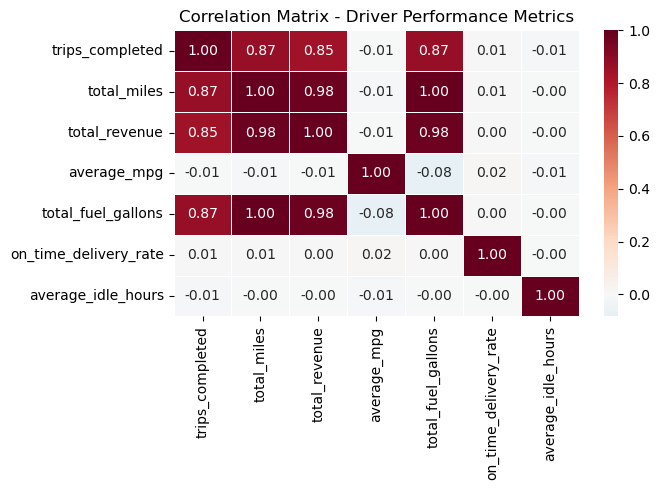

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='RdBu_r',
    center=0,
    fmt='.2f',
    linewidths=0.5)

plt.title('Correlation Matrix - Driver Performance Metrics')

plt.tight_layout()
plt.show()

Analizaremos fundamentalmente la relación entre trips_completed y total revenue, así como total_miles y total_revenue.

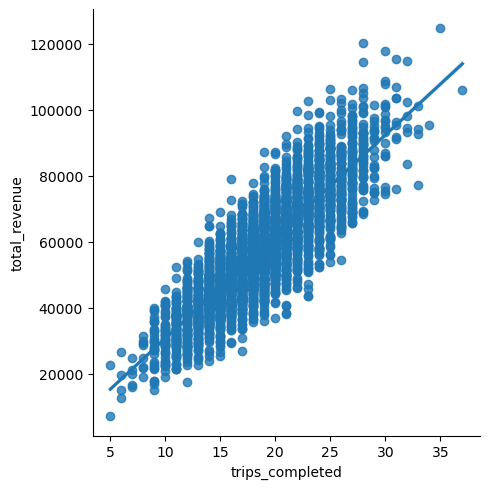

In [11]:
sns.lmplot(data= driver_monthly_metrics,
            x= 'trips_completed',
            y= 'total_revenue');

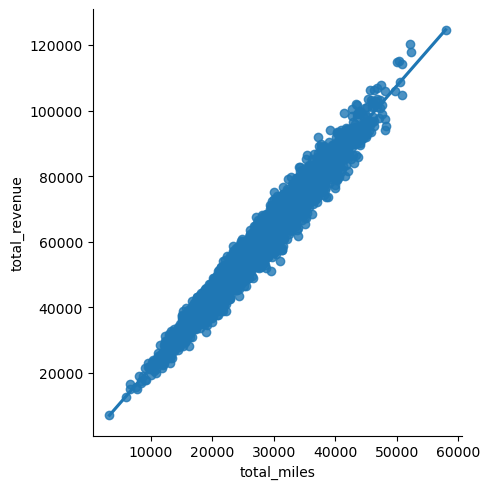

In [12]:
sns.lmplot(data= driver_monthly_metrics,
            x= 'total_miles',
            y= 'total_revenue');

El análisis de correlación muestra que el rendimiento económico de los conductores está principalmente asociado al volumen de actividad (viajes completados y millas recorridas), mientras que variables como la eficiencia del combustible, la puntualidad, etc, presentan una relación muy débil con los ingresos.

In [13]:
# Contruiremos métricas para evaluar el desempeño de los conductores

driver_monthly_metrics['revenue_per_trip'] = (
    driver_monthly_metrics['total_revenue'] / driver_monthly_metrics['trips_completed'])

driver_monthly_metrics['revenue_per_mile'] = (
    driver_monthly_metrics['total_revenue'] / driver_monthly_metrics['total_miles'])

driver_monthly_metrics['fuel_per_mile'] = (
    driver_monthly_metrics['total_fuel_gallons'] / driver_monthly_metrics['total_miles'])

In [14]:
driver_monthly_metrics[[
        'revenue_per_trip',
        'revenue_per_mile',
        'fuel_per_mile']].describe().T

,count,mean,std,min,25%,50%,75%,max
revenue_per_trip,4464.0,3073.845042,461.159367,1419.312000,2762.626806,3063.938278,3379.423676,4943.210625
revenue_per_mile,4464.0,2.149331,0.116501,1.709787,2.072481,2.150259,2.227765,2.543812
fuel_per_mile,4464.0,0.155089,0.003835,0.140939,0.152505,0.155117,0.157692,0.168170


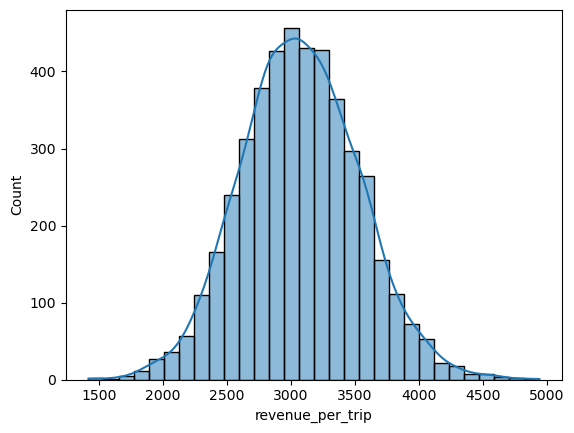

In [15]:
sns.histplot(data= driver_monthly_metrics,
            x= 'revenue_per_trip',
            bins= 30,
            kde= True);

El ingreso generado por viaje presenta una distribución aproximadamente normal, con una media cercana a los 3.074 dólares y sin evidencias de valores extremos significativos, lo que sugiere una operación relativamente homogénea entre conductores. Además, las otra dos métricas tienen muy poca variabilidad.

In [16]:
driver_summary = (                         # Resumir la media de las principales variables por conductor.
    driver_monthly_metrics
    .groupby('driver_id')
    .agg({
        'trips_completed':'mean',
        'total_revenue':'mean',
        'total_miles':'mean',
        'average_mpg':'mean',
        'average_idle_hours':'mean',
        'on_time_delivery_rate':'mean',
        'revenue_per_trip':'mean',
        'revenue_per_mile':'mean',
        'fuel_per_mile':'mean'}).round(2))
driver_summary        

,trips_completed,total_revenue,total_miles,average_mpg,average_idle_hours,on_time_delivery_rate,revenue_per_trip,revenue_per_mile,fuel_per_mile
driver_id,,,,,,,,,
DRV00001,17.56,55157.87,25839.89,6.48,7.04,0.45,3165.54,2.13,0.16
DRV00002,18.39,57600.60,26201.28,6.50,7.11,0.47,3119.82,2.19,0.15
DRV00003,18.81,59638.26,28062.08,6.54,6.80,0.45,3179.39,2.12,0.15
DRV00004,18.31,58871.15,27295.14,6.52,7.00,0.43,3215.67,2.16,0.15
DRV00005,17.86,56176.60,25642.44,6.51,7.14,0.45,3145.02,2.19,0.16
...,...,...,...,...,...,...,...,...,...
DRV00146,18.75,58128.00,26818.11,6.48,7.15,0.42,3092.66,2.17,0.16
DRV00147,19.58,62668.53,28865.47,6.50,6.95,0.45,3211.42,2.17,0.16
DRV00148,18.92,56560.26,26203.56,6.51,7.05,0.46,2995.13,2.16,0.16


Conclusiones parciales:
- Las variables relacionadas con actividad (viajes, millas e ingresos) presentan una fuerte relación positiva, mientras que las métricas de eficiencia muestran una correlación muy baja.
- El incremento de los ingresos está principalmente relacionado con una mayor actividad operativa.
- Los indicadores presentan una distribución bastante homogénea entre conductores.

*** 3.2- Rendimiento de la flota ***

In [17]:
truck_utilization_metrics.describe().T

,count,mean,min,25%,50%,75%,max,std
month,3312,2023-06-16 18:40:00,2022-01-01 00:00:00,2022-09-23 12:00:00,2023-06-16 00:00:00,2024-03-08 18:00:00,2024-12-01 00:00:00,NaN
trips_completed,3312.0,25.283213,11.0,22.0,25.0,29.0,46.0,5.097786
total_miles,3312.0,36152.230072,12680.0,30443.5,35758.0,41550.75,71177.0,8213.091728
total_revenue,3312.0,77700.561564,27876.18,65213.7025,76607.69,89556.515,144891.1,17995.268042
average_mpg,3312.0,6.500975,6.01,6.42,6.5,6.58,6.86,0.115717
maintenance_events,3312.0,0.673309,0.0,0.0,0.0,1.0,4.0,0.814494
maintenance_cost,3312.0,1307.18763,0.0,0.0,0.0,2409.79,10414.66,1835.021274
downtime_hours,3312.0,16.549577,0.0,0.0,0.0,30.2,152.2,22.997205
utilization_rate,3312.0,0.830447,0.387,0.71,0.833,0.935,1.484,0.166084


In [18]:
trucks_corr = truck_utilization_metrics[[
    'trips_completed',
    'total_miles',
    'total_revenue',
    'utilization_rate',
    'maintenance_cost',
    'maintenance_events',
    'downtime_hours',
    'average_mpg']]

corr_matrix = trucks_corr.corr(method='pearson')
corr_matrix

,trips_completed,total_miles,total_revenue,utilization_rate,maintenance_cost,maintenance_events,downtime_hours,average_mpg
trips_completed,1.000000,0.875485,0.857169,0.991245,0.004681,-0.009715,-0.012505,0.019551
total_miles,0.875485,1.000000,0.980881,0.867047,0.002081,-0.011396,-0.009592,0.002802
total_revenue,0.857169,0.980881,1.000000,0.848524,0.000339,-0.012722,-0.011020,-0.002580
utilization_rate,0.991245,0.867047,0.848524,1.000000,-0.000970,-0.015120,-0.017699,0.017704
maintenance_cost,0.004681,0.002081,0.000339,-0.000970,1.000000,0.864558,0.760698,-0.005999
maintenance_events,-0.009715,-0.011396,-0.012722,-0.015120,0.864558,1.000000,0.879506,-0.007482
downtime_hours,-0.012505,-0.009592,-0.011020,-0.017699,0.760698,0.879506,1.000000,-0.006390
average_mpg,0.019551,0.002802,-0.002580,0.017704,-0.005999,-0.007482,-0.006390,1.000000


In [19]:
fig = px.imshow(
    corr_matrix,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    title="Correlation Matrix")

fig.update_layout(
    title={
        "text": "Correlation Matrix",
        "x": 0.5,
        "xanchor": "center"},
    width=700,
    height=600,
    margin=dict(l=20, r=20, t=70, b=40),
    template="plotly_white")

fig.show()

In [20]:
fig = px.scatter(
    truck_utilization_metrics,
    x= 'utilization_rate',
    y= 'total_revenue',
    title='Utilization Rate vs Revenue')

fig.show()

Se observa una relación positiva clara entre la tasa de utilización de los vehículos y los ingresos generados. Los camiones con una mayor utilización tienden a generar mayores ingresos mensuales, lo que confirma que la utilización de la flota constituye uno de los principales factores asociados al rendimiento económico.

In [21]:
fig = px.scatter(
    truck_utilization_metrics,
    x= 'maintenance_events',
    y= 'downtime_hours',
    title=' Maintenance_events vs Downtime_hours')

fig.show()

Los vehículos que requieren un mayor número de intervenciones de mantenimiento presentan un incremento progresivo del tiempo de inactividad, lo que puede afectar a su disponibilidad operativa.

In [22]:
fig = px.scatter(
    truck_utilization_metrics,
    x= 'maintenance_cost',
    y= 'downtime_hours',
    title=' Maintenance_cost vs Downtime_hours')

fig.show()

Aunque existe una relación positiva entre el coste de mantenimiento y el tiempo de inactividad, la dispersión observada indica que otros factores también influyen en la disponibilidad de los vehículos.

Conclusión parcial:

El análisis evidencia que la rentabilidad de la flota depende principalmente del nivel de utilización de los vehículos, mientras que la disponibilidad operativa está condicionada por la frecuencia de las intervenciones de mantenimiento y el tiempo de inactividad asociado. Estos resultados ponen de manifiesto la necesidad de equilibrar la utilización de los activos con una planificación eficiente del mantenimiento para maximizar el rendimiento operativo.

*** 3.3- Análisis de rentabilidad de las operaciones ***

3.3.1 - Clientes

In [23]:
customer_summary = (                          # Como se distribuye la operacion entre clientes
    loads
    .groupby('customer_id')
    .agg(
        total_revenue=('revenue', 'sum'),
        total_loads=('load_id', 'count'),
        avg_revenue=('revenue', 'mean'))
    .sort_values(by='total_revenue', ascending=False))

customer_summary.round(2)

,total_revenue,total_loads,avg_revenue
customer_id,,,
CUST00200,1544419.81,476,3244.58
CUST00181,1542321.02,497,3103.26
CUST00077,1521982.07,487,3125.22
CUST00097,1487129.31,470,3164.10
CUST00122,1483188.90,463,3203.43
...,...,...,...
CUST00109,1152769.50,375,3074.05
CUST00151,1148596.86,374,3071.11
CUST00071,1142845.27,383,2983.93


In [24]:
customer_summary['revenue_pct'] = (                   # Calcula el % con respecto al total
    customer_summary['total_revenue']
    / customer_summary['total_revenue'].sum())

In [25]:
customer_summary['cum_revenue_pct'] = (               # Porcentaje acumulado
    customer_summary['revenue_pct'].cumsum())

customer_summary.head()

,total_revenue,total_loads,avg_revenue,revenue_pct,cum_revenue_pct
customer_id,,,,,
CUST00200,1544419.81,476,3244.579433,0.005883,0.005883
CUST00181,1542321.02,497,3103.261610,0.005875,0.011758
CUST00077,1521982.07,487,3125.219856,0.005797,0.017555
CUST00097,1487129.31,470,3164.104915,0.005665,0.023220
CUST00122,1483188.90,463,3203.431749,0.005650,0.028870


In [26]:
n_customers_80 = (customer_summary['cum_revenue_pct'] <= 0.80).sum()     # Cuantos clientes generan el 80% de los ingresos 

print(n_customers_80)

155


In [27]:
customer_loads = loads.merge(
    customers[
        ['customer_id',
         'customer_type',
         'primary_freight_type']
    ],
    on='customer_id',
    how='left')

customer_loads.head() 

,load_id,customer_id,route_id,load_date,load_type,weight_lbs,pieces,revenue,fuel_surcharge,accessorial_charges,load_status,booking_type,customer_type,primary_freight_type
0,LOAD00000001,CUST00183,RTE00019,2022-01-01,Dry Van,19178,13,3045.23,406.72,100,Completed,Spot,Spot,Electronics
1,LOAD00000002,CUST00076,RTE00058,2022-01-01,Dry Van,27761,22,1224.48,98.61,0,Completed,Dedicated,Spot,Electronics
2,LOAD00000003,CUST00027,RTE00048,2022-01-01,Refrigerated,35594,16,7171.12,792.88,0,Completed,Spot,Spot,Automotive
3,LOAD00000004,CUST00088,RTE00013,2022-01-01,Refrigerated,33274,10,1308.20,141.33,50,Completed,Spot,Dedicated,Consumer Goods
4,LOAD00000005,CUST00185,RTE00020,2022-01-01,Dry Van,40257,10,3317.18,738.48,0,Completed,Spot,Contract,Electronics


In [28]:
customer_loads.groupby('customer_type').agg(     # Modalidada de contrato que genera más ingresos
    total_revenue=('revenue','sum'),
    total_loads=('load_id','count'),
    avg_revenue=('revenue','mean')).round(2)

,total_revenue,total_loads,avg_revenue
customer_type,,,
Contract,98795209.72,32209,3067.32
Dedicated,80878634.21,26345,3069.98
Spot,82851956.36,26856,3085.04


In [29]:
customer_loads.groupby('primary_freight_type').agg(      # Como se comportan los indicadores de los tipos de carga.
    total_revenue=('revenue','sum'),
    total_loads=('load_id','count'),
    avg_revenue=('revenue','mean')).round(2)

,total_revenue,total_loads,avg_revenue
primary_freight_type,,,
Automotive,54714817.93,17641,3101.57
Consumer Goods,38962611.46,12622,3086.88
Electronics,42812842.47,13988,3060.68
Food/Beverage,48578649.67,15898,3055.65
General,31348639.53,10199,3073.70
Retail,46108239.23,15062,3061.23


Conclusiones parciales:
- El análisis evidencia que la empresa mantiene una cartera de clientes diversificada, sin una dependencia excesiva de un reducido número de clientes. Asimismo, el segmento Contract concentra el mayor volumen de ingresos y operaciones, mientras que las modalidades Dedicated y Spot presentan una participación similar.

- Por otro lado, el ingreso medio por carga permanece estable entre los distintos tipos de cliente y categorías de mercancía, lo que sugiere que las diferencias de facturación están asociadas principalmente al volumen de operaciones realizadas y no al valor económico individual de cada carga.

3.3.2 - Rutas

In [30]:
routes.head()

,route_id,origin_city,origin_state,destination_city,destination_state,typical_distance_miles,base_rate_per_mile,fuel_surcharge_rate,typical_transit_days
0,RTE00001,Atlanta,GA,Chicago,IL,677,1.70,0.19,1
1,RTE00002,Atlanta,GA,Miami,FL,697,2.08,0.22,1
2,RTE00003,Chicago,IL,Los Angeles,CA,2003,2.55,0.29,3
3,RTE00004,Chicago,IL,Portland,OR,2017,1.84,0.19,3
4,RTE00005,Chicago,IL,Las Vegas,NV,1749,2.41,0.26,3


In [31]:
loads['route_id'].nunique()

58

In [32]:
routes['route_id'].nunique()

58

In [33]:
route_loads = loads.merge(routes, on='route_id', how='left')

In [34]:
route_summary = (
    route_loads
    .groupby('route_id')
    .agg(
        total_revenue=('revenue', 'sum'),
        total_loads=('load_id', 'count'),
        avg_revenue=('revenue', 'mean'),
        typical_distance=('typical_distance_miles', 'first'),
        base_rate=('base_rate_per_mile', 'first'),
        transit_days=('typical_transit_days', 'first')))

In [35]:
route_summary.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
total_revenue,58.0,4526306.90,2755376.75,217573.05,2105675.29,4213668.93,6233849.81,10069054.22
total_loads,58.0,1472.59,38.06,1386.00,1447.75,1472.00,1491.00,1628.00
avg_revenue,58.0,3078.65,1869.58,148.21,1410.21,2941.09,4204.82,7077.37
typical_distance,58.0,1391.50,782.83,92.00,700.75,1271.00,2085.25,3141.00
base_rate,58.0,2.20,0.37,1.52,1.90,2.23,2.48,2.79
transit_days,58.0,2.12,1.16,1.00,1.00,2.00,3.00,5.00


- La empresa opera en rutas tanto de corta (92 millas) como larga distancia (3141 millas)
- La política de tarifa se mantiene bastante homogénea. 
- Todas las rutas tienen un volumen parecido de carga (Desviación = 38).

In [36]:
route_summary[                    # Correlación para ver la reación real entre las variables
    ['typical_distance',
     'base_rate',
     'transit_days',
     'total_revenue',
     'avg_revenue',
     'total_loads']].corr()

,typical_distance,base_rate,transit_days,total_revenue,avg_revenue,total_loads
typical_distance,1.000000,0.075202,0.959623,0.940065,0.941762,-0.112111
base_rate,0.075202,1.000000,0.113300,0.359681,0.359905,0.013302
transit_days,0.959623,0.113300,1.000000,0.909218,0.910619,-0.063453
total_revenue,0.940065,0.359681,0.909218,1.000000,0.999005,-0.069060
avg_revenue,0.941762,0.359905,0.910619,0.999005,1.000000,-0.104000
total_loads,-0.112111,0.013302,-0.063453,-0.069060,-0.104000,1.000000


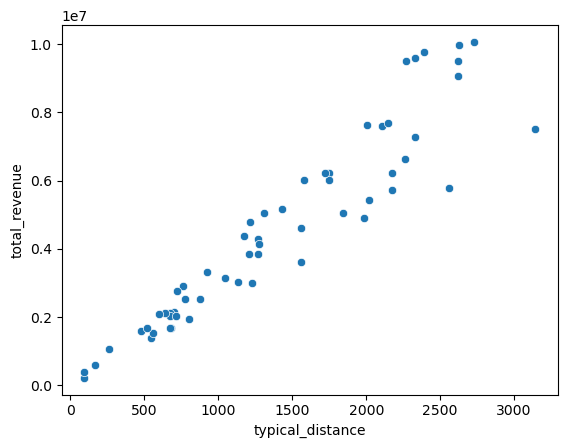

In [37]:
sns.scatterplot(data= route_summary,
                x= 'typical_distance',
                y= 'total_revenue');

- La distancia de las rutas constituye el principal factor asociado a los ingresos generados, mientras que la tarifa base por milla presenta una influencia moderada. 
- El volumen de cargas por ruta permanece prácticamente constante, lo que sugiere una distribución homogénea de la actividad entre las rutas disponibles.

3.3.3 - Seguridad Operacional (Safety_Incidents)

In [38]:
safety_incidents.head(3)


,incident_id,trip_id,truck_id,driver_id,incident_date,incident_type,location_city,location_state,at_fault_flag,injury_flag,vehicle_damage_cost,cargo_damage_cost,claim_amount,preventable_flag,description
0,INC00000001,TRIP00036079,TRK00006,DRV00006,2023-04-09 14:00:00,Moving Violation,Columbus,PA,True,False,12629.26,0.00,12629.26,True,Severe incident involving equipment
1,INC00000002,TRIP00032462,TRK00084,DRV00006,2023-02-19 11:00:00,Moving Violation,Columbus,NC,False,False,2700.70,14284.24,16984.94,False,Severe incident involving weather
2,INC00000003,TRIP00067583,TRK00106,DRV00119,2024-05-20 01:00:00,Customer Complaint,Seattle,OK,True,False,24302.32,0.00,24302.32,True,Minor incident involving traffic


In [39]:
safety_incidents.describe().T

,count,mean,min,25%,50%,75%,max,std
incident_date,170,2023-07-04 19:05:38.823529472,2022-01-05 02:00:00,2022-09-12 19:45:00,2023-06-13 15:30:00,2024-04-26 06:00:00,2024-12-24 09:00:00,NaN
vehicle_damage_cost,170.0,9432.712412,0.0,0.0,8035.265,17688.7425,24614.16,8549.031425
cargo_damage_cost,170.0,6174.180647,0.0,0.0,0.0,1790.5625,49744.07,12989.250393
claim_amount,170.0,15606.893059,0.0,2108.275,13627.185,21988.7875,64245.72,15082.128331


In [40]:
safety_incidents['incident_type'].value_counts()

incident_type
DOT Violation         39
Equipment Damage      35
Accident              35
Customer Complaint    34
Moving Violation      27
Name: count, dtype: int64

In [41]:
safety_incidents['preventable_flag'].value_counts(normalize=True)

preventable_flag
False    0.623529
True     0.376471
Name: proportion, dtype: float64

In [42]:
safety_incidents['at_fault_flag'].value_counts(normalize=True)

at_fault_flag
False    0.682353
True     0.317647
Name: proportion, dtype: float64

In [43]:
safety_incidents['injury_flag'].value_counts(normalize=True)

injury_flag
False    0.805882
True     0.194118
Name: proportion, dtype: float64

In [44]:
safety_incidents['total_incident_cost'] = (          # Coste total por diferentes conceptos
    safety_incidents['vehicle_damage_cost']
    + safety_incidents['cargo_damage_cost']
    + safety_incidents['claim_amount'])
safety_incidents.head()

,incident_id,trip_id,truck_id,driver_id,incident_date,incident_type,location_city,location_state,at_fault_flag,injury_flag,vehicle_damage_cost,cargo_damage_cost,claim_amount,preventable_flag,description,total_incident_cost
0,INC00000001,TRIP00036079,TRK00006,DRV00006,2023-04-09 14:00:00,Moving Violation,Columbus,PA,True,False,12629.26,0.00,12629.26,True,Severe incident involving equipment,25258.52
1,INC00000002,TRIP00032462,TRK00084,DRV00006,2023-02-19 11:00:00,Moving Violation,Columbus,NC,False,False,2700.70,14284.24,16984.94,False,Severe incident involving weather,33969.88
2,INC00000003,TRIP00067583,TRK00106,DRV00119,2024-05-20 01:00:00,Customer Complaint,Seattle,OK,True,False,24302.32,0.00,24302.32,True,Minor incident involving traffic,48604.64
3,INC00000004,TRIP00049128,TRK00085,DRV00134,2023-09-26 03:00:00,Equipment Damage,Kansas City,TN,True,False,4879.13,0.00,4879.13,True,Moderate incident involving equipment,9758.26
4,INC00000005,TRIP00062884,TRK00014,DRV00133,2024-03-20 14:00:00,DOT Violation,Las Vegas,IN,False,False,14951.40,0.00,14951.40,False,Minor incident involving other driver,29902.80


In [45]:
safety_incidents['total_incident_cost'].describe()

count       170.000000
mean      31213.786118
std       30164.256661
min           0.000000
25%        4216.550000
50%       27254.370000
75%       43977.575000
max      128491.440000
Name: total_incident_cost, dtype: float64

In [46]:
safety_incidents.groupby('incident_type').agg(          # Impacto económico por tipo de incidente
    incidents=('incident_id','count'),
    avg_cost=('total_incident_cost','mean'),
    total_cost=('total_incident_cost','sum'))

,incidents,avg_cost,total_cost
incident_type,,,
Accident,35,27852.465143,974836.28
Customer Complaint,34,25440.702353,864983.88
DOT Violation,39,29817.806154,1162894.44
Equipment Damage,35,42341.184571,1481941.46
Moving Violation,27,30432.873333,821687.58


In [47]:
safety_incidents.groupby('preventable_flag').agg(       # Analizar coste de incidentes evitables y no evitables.
    avg_cost=('total_incident_cost','mean'),
    median_cost=('total_incident_cost','median'))

,avg_cost,median_cost
preventable_flag,,
False,32994.261509,32443.48
True,28264.873750,19344.10


In [48]:
incident_summary = (
    safety_incidents
    .groupby('incident_type')
    .agg(
        incidents=('incident_id', 'count'),
        avg_vehicle_damage=('vehicle_damage_cost', 'mean'),
        avg_cargo_damage=('cargo_damage_cost', 'mean'),
        avg_claim=('claim_amount', 'mean'),
        avg_total_cost=('total_incident_cost', 'mean'),
        total_cost=('total_incident_cost', 'sum'),
        preventable_rate=('preventable_flag', 'mean'),
        at_fault_rate=('at_fault_flag', 'mean'),
        injury_rate=('injury_flag', 'mean')).round(2))

incident_summary

,incidents,avg_vehicle_damage,avg_cargo_damage,avg_claim,avg_total_cost,total_cost,preventable_rate,at_fault_rate,injury_rate
incident_type,,,,,,,,,
Accident,35,9656.87,4269.36,13926.23,27852.47,974836.28,0.40,0.23,0.11
Customer Complaint,34,10345.39,2374.96,12720.35,25440.70,864983.88,0.38,0.24,0.29
DOT Violation,39,7698.79,7210.11,14908.90,29817.81,1162894.44,0.46,0.41,0.13
Equipment Damage,35,11664.31,9506.28,21170.59,42341.18,1481941.46,0.26,0.40,0.29
Moving Violation,27,7604.58,7611.86,15216.44,30432.87,821687.58,0.37,0.30,0.15


Text(0.5, 1.0, 'Distribution of Incident Costs by Incident Type')

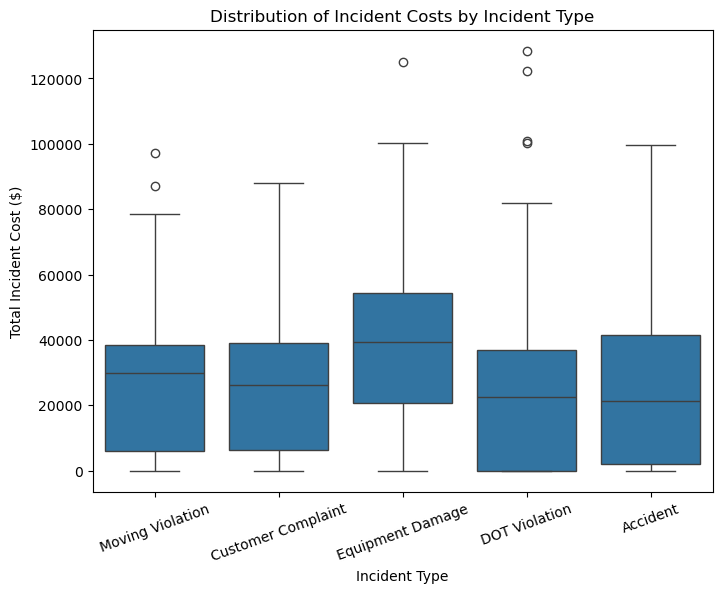

In [49]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=safety_incidents,
    x='incident_type',
    y='total_incident_cost'
)

plt.xticks(rotation=20)
plt.ylabel('Total Incident Cost ($)')
plt.xlabel('Incident Type')
plt.title('Distribution of Incident Costs by Incident Type')

Conclusiones parciales:

- Los incidentes tienen un impacto económico heterogéneo figurando Equipment Damage como el más representativo.

- El incidente como mayor frecuencia es el DOT Violation, sin embargo no es el que mayor impacto económico causa.

- Los incidentes inevitables son mayores que los evitables, lo cual se pone de manifiesto que no siemore depende de la empresa.

- Los costes asociados a los mismos se muestran variables, fundamentalmente en Equipment Damage y Accident.

**** ANALISIS VARIOS DE VARIOS INDICADORES ****

In [7]:
trucks.head()

,truck_id,unit_number,make,model_year,vin,acquisition_date,acquisition_mileage,fuel_type,tank_capacity_gallons,status,home_terminal
0,TRK00001,3463,Peterbilt,2016,1VV205190335317039,2017-04-27,18814,Diesel,200,Active,Omaha
1,TRK00002,6461,Kenworth,2015,1NV753749606229960,2018-10-04,26795,Diesel,150,Active,Seattle
2,TRK00003,2335,Peterbilt,2018,1NT803101860493229,2020-09-17,11795,Diesel,150,Maintenance,Atlanta
3,TRK00004,3317,Freightliner,2015,1VV131945381692351,2017-06-17,8875,Diesel,200,Active,Salt Lake City
4,TRK00005,6731,Freightliner,2016,1FT822215709701985,2021-10-08,42042,Diesel,250,Maintenance,Miami


In [ ]:
maintenance_sorted = maintenance_records.sort_values( by="maintenance_date")     # Análisis para ver si todos los trucks han pasado por mantenimiento
maintenance_sorted.head()

,maintenance_id,truck_id,maintenance_date,maintenance_type,odometer_reading,labor_hours,labor_cost,parts_cost,total_cost,facility_location,downtime_hours,service_description
0,MAINT00000001,TRK00085,2022-01-01,Inspection,400255,7.8,781.42,10.41,791.83,Kansas City,22.2,Emergency Inspection
1,MAINT00000002,TRK00041,2022-01-01,Tire,268041,0.9,80.91,3207.16,3288.07,Seattle,8.0,Scheduled Tire
2,MAINT00000003,TRK00090,2022-01-01,Preventive,698915,7.2,733.18,1570.57,2303.75,Miami,16.5,Routine Preventive
3,MAINT00000004,TRK00056,2022-01-02,Inspection,416522,2.8,298.80,67.48,366.28,Kansas City,34.6,Emergency Inspection
4,MAINT00000005,TRK00029,2022-01-02,Repair,179968,4.6,409.08,982.59,1391.67,Omaha,4.4,Emergency Repair


In [10]:
last_odometer = (
    maintenance_sorted
    .groupby("truck_id")
    .last()[["odometer_reading"]]
    .reset_index())

last_odometer.head()

,truck_id,odometer_reading
0,TRK00001,351017
1,TRK00002,526278
2,TRK00003,484373
3,TRK00004,349248
4,TRK00005,651190


In [11]:
len(last_odometer)

120

In [12]:
trucks["truck_id"].nunique()

120

In [ ]:
trucks["truck_id"].isin(last_odometer["truck_id"]).value_counts()    # Comprobar que cada truck ha tenido un mantenimiento.

truck_id
True    120
Name: count, dtype: int64